## Model Comparison — K-Means vs Agglomerative Clustering
Compares the two clustering approaches on the same AfroPulse feature set (views, likes, comments).
Uses three standard unsupervised accuracy metrics to determine which model produces better-defined clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

# ── 1. PREPARE DATA ──────────────────────────────────────────────────────────
# Load and clean (same pipeline as the main notebook)
df_raw = pd.read_csv("afropulse_dataset_final.csv")
df_raw["upload_date"] = pd.to_datetime(df_raw["upload_date"], utc=True, errors="coerce").dt.tz_localize(None)
df_raw["year"] = df_raw["upload_date"].dt.year

cluster_df = df_raw[df_raw["genre"] != "Other"].copy()
for col in ["views", "likes", "comments"]:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")
cluster_df.dropna(subset=["views", "likes", "comments"], inplace=True)
cluster_df.reset_index(drop=True, inplace=True)

features = cluster_df[["views", "likes", "comments"]].copy()
scaler = StandardScaler()
X = scaler.fit_transform(features)

N_CLUSTERS = 4
print(f"Dataset ready: {len(cluster_df):,} songs, {N_CLUSTERS} clusters")

Dataset ready: 1,288 songs, 4 clusters


In [2]:
# ── 2. FIT BOTH MODELS ───────────────────────────────────────────────────────

# K-Means
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

# Agglomerative (Ward linkage — best for compact, spherical clusters)
agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward")
ag_labels = agglo.fit_predict(X)

print("Both models fitted.")

Both models fitted.


C:\Users\njeat\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [3]:
# ── 3. SCORE BOTH MODELS ─────────────────────────────────────────────────────
#
# Silhouette Score   → Higher is better  (range: -1 to 1)
#   Measures how similar each point is to its own cluster vs other clusters.
#
# Davies-Bouldin Index → Lower is better (range: 0 to ∞)
#   Measures the average ratio of within-cluster scatter to between-cluster separation.
#
# Calinski-Harabasz Score → Higher is better (range: 0 to ∞)
#   Ratio of between-cluster dispersion to within-cluster dispersion.

results = {}
for name, labels in [("K-Means", km_labels), ("Agglomerative", ag_labels)]:
    sil   = silhouette_score(X, labels)
    db    = davies_bouldin_score(X, labels)
    ch    = calinski_harabasz_score(X, labels)
    results[name] = {"Silhouette ↑": round(sil, 4),
                     "Davies-Bouldin ↓": round(db, 4),
                     "Calinski-Harabasz ↑": round(ch, 2)}

scores_df = pd.DataFrame(results).T

# Determine winner per metric
winners = {
    "Silhouette ↑":          scores_df["Silhouette ↑"].idxmax(),
    "Davies-Bouldin ↓":      scores_df["Davies-Bouldin ↓"].idxmin(),
    "Calinski-Harabasz ↑":   scores_df["Calinski-Harabasz ↑"].idxmax(),
}

print("=" * 55)
print(f"{'Metric':<25} {'K-Means':>12} {'Agglomerative':>14}  Winner")
print("-" * 55)
for metric, row in scores_df.items():
    print(f"{metric:<25} {row['K-Means']:>12} {row['Agglomerative']:>14}  ← {winners[metric]}")
print("=" * 55)

km_wins  = sum(1 for v in winners.values() if v == "K-Means")
ag_wins  = sum(1 for v in winners.values() if v == "Agglomerative")
overall  = "K-Means" if km_wins >= ag_wins else "Agglomerative"
print(f"\nOverall winner: {overall} ({max(km_wins, ag_wins)}/3 metrics)")

Metric                         K-Means  Agglomerative  Winner
-------------------------------------------------------
Silhouette ↑                    0.6602         0.6663  ← Agglomerative
Davies-Bouldin ↓                0.6715         0.7025  ← K-Means
Calinski-Harabasz ↑             806.62         761.66  ← K-Means

Overall winner: K-Means (2/3 metrics)


In [4]:
# ── 4. CLUSTER AGREEMENT TABLE ───────────────────────────────────────────────
# Shows how much the two models agree on cluster assignments.
# High numbers on the diagonal = strong agreement.

agreement = pd.crosstab(
    pd.Series(km_labels,  name="K-Means cluster"),
    pd.Series(ag_labels,  name="Agglomerative cluster")
)
print("Cluster Assignment Agreement (rows = K-Means, cols = Agglomerative)")
print("Each cell = number of songs assigned to that pair of clusters.")
print()
print(agreement)

# Agreement % — how many songs landed in the dominant matching cluster
matched = sum(agreement.max(axis=1))  # best match for each K-Means cluster
pct = matched / len(km_labels) * 100
print(f"\nBest-match agreement: {matched:,} / {len(km_labels):,} songs ({pct:.1f}%)")

Cluster Assignment Agreement (rows = K-Means, cols = Agglomerative)
Each cell = number of songs assigned to that pair of clusters.

Agglomerative cluster    0     1   2  3
K-Means cluster                        
0                       13  1051   0  0
1                      174    37   0  0
2                        0     0  12  0
3                        0     0   0  1

Best-match agreement: 1,238 / 1,288 songs (96.1%)


In [5]:
# ── 5. CLUSTER SIZE COMPARISON ───────────────────────────────────────────────
# Uneven cluster sizes can be a sign of poor fit.

km_sizes = pd.Series(km_labels).value_counts().sort_index()
ag_sizes = pd.Series(ag_labels).value_counts().sort_index()

print("Cluster sizes — K-Means:")
for k, v in km_sizes.items():
    print(f"  Cluster {k}: {v:>5,} songs  ({v/len(km_labels)*100:.1f}%)")

print("\nCluster sizes — Agglomerative:")
for k, v in ag_sizes.items():
    print(f"  Cluster {k}: {v:>5,} songs  ({v/len(ag_labels)*100:.1f}%)")

Cluster sizes — K-Means:
  Cluster 0: 1,064 songs  (82.6%)
  Cluster 1:   211 songs  (16.4%)
  Cluster 2:    12 songs  (0.9%)
  Cluster 3:     1 songs  (0.1%)

Cluster sizes — Agglomerative:
  Cluster 0:   187 songs  (14.5%)
  Cluster 1: 1,088 songs  (84.5%)
  Cluster 2:    12 songs  (0.9%)
  Cluster 3:     1 songs  (0.1%)


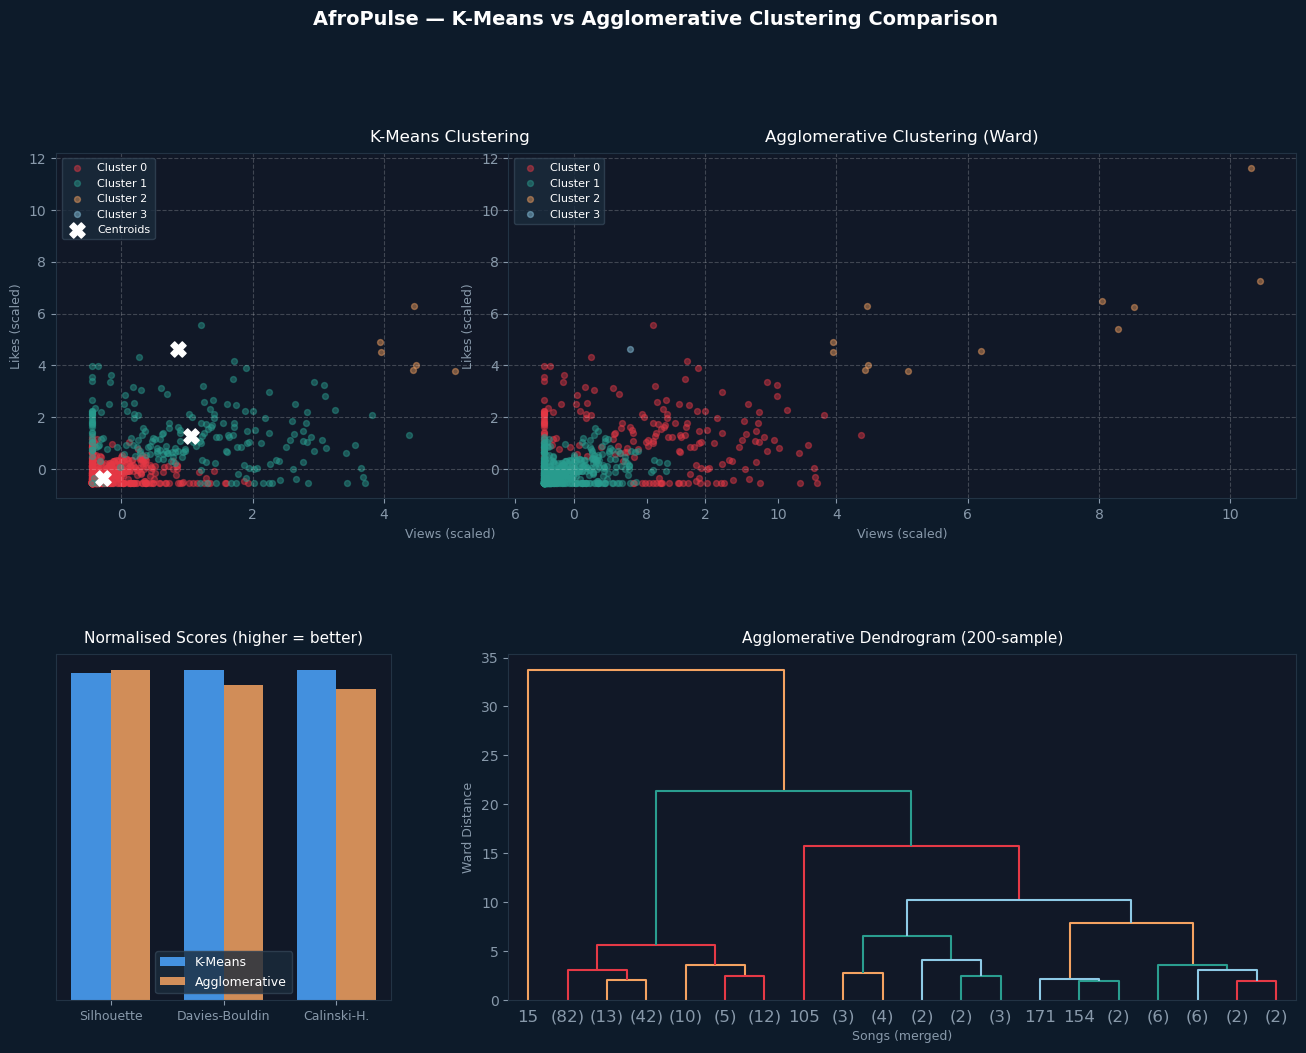

Saved → clustering_comparison.png


In [6]:
# ── 6. VISUALISATION ─────────────────────────────────────────────────────────
# Side-by-side scatter plots (Views vs Likes), coloured by cluster assignment.
# Bottom row: metric bar chart and dendrogram.

COLOURS = ["#e63946", "#2a9d8f", "#f4a261", "#8ecae6"]

fig = plt.figure(figsize=(16, 11), facecolor="#0d1b2a")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_km   = fig.add_subplot(gs[0, 0:2])
ax_ag   = fig.add_subplot(gs[0, 1:3])
ax_bar  = fig.add_subplot(gs[1, 0])
ax_dend = fig.add_subplot(gs[1, 1:3])

# Shared axis style
def style_ax(ax, title):
    ax.set_facecolor("#111827")
    ax.tick_params(colors="#8899aa")
    for spine in ax.spines.values():
        spine.set_edgecolor("#223344")
    ax.set_title(title, color="white", fontsize=12, pad=8)
    ax.set_xlabel("Views (scaled)", color="#8899aa", fontsize=9)
    ax.set_ylabel("Likes (scaled)", color="#8899aa", fontsize=9)
    ax.grid(linestyle="--", alpha=0.2, color="white")

# K-Means scatter
for k in range(N_CLUSTERS):
    mask = km_labels == k
    ax_km.scatter(X[mask, 0], X[mask, 1], c=COLOURS[k],
                  alpha=0.45, s=18, label=f"Cluster {k}")
ax_km.scatter(kmeans.cluster_centers_[:, 0],
              kmeans.cluster_centers_[:, 1],
              c="white", marker="X", s=120, zorder=5, label="Centroids")
style_ax(ax_km, "K-Means Clustering")
ax_km.legend(fontsize=8, labelcolor="white",
             facecolor="#1a2b3c", edgecolor="#334455")

# Agglomerative scatter
for k in range(N_CLUSTERS):
    mask = ag_labels == k
    ax_ag.scatter(X[mask, 0], X[mask, 1], c=COLOURS[k],
                  alpha=0.45, s=18, label=f"Cluster {k}")
style_ax(ax_ag, "Agglomerative Clustering (Ward)")
ax_ag.legend(fontsize=8, labelcolor="white",
             facecolor="#1a2b3c", edgecolor="#334455")

# Metric comparison bar chart
metrics   = ["Silhouette", "Davies-Bouldin", "Calinski-H."]  
km_vals   = [results["K-Means"][k]     for k in results["K-Means"]]
ag_vals   = [results["Agglomerative"][k] for k in results["Agglomerative"]]

# Normalise each metric to [0,1] for comparison on same axis
def norm(a, b, higher_better=True):
    """Return (normed_a, normed_b) where the winner is 1.0."""
    if higher_better:
        mx = max(a, b)
        return (a/mx if mx else 0, b/mx if mx else 0)
    else:  # lower better — invert
        mn = min(a, b)
        return (mn/a if a else 0, mn/b if b else 0)

sil_n  = norm(km_vals[0], ag_vals[0], higher_better=True)
db_n   = norm(km_vals[1], ag_vals[1], higher_better=False)
ch_n   = norm(km_vals[2], ag_vals[2], higher_better=True)

normed_km = [sil_n[0], db_n[0], ch_n[0]]
normed_ag = [sil_n[1], db_n[1], ch_n[1]]

x = np.arange(3)
w = 0.35
ax_bar.set_facecolor("#111827")
ax_bar.bar(x - w/2, normed_km, w, color="#4da6ff", label="K-Means",       alpha=0.85)
ax_bar.bar(x + w/2, normed_ag, w, color="#f4a261", label="Agglomerative", alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics, color="#8899aa", fontsize=9)
ax_bar.set_yticks([])
ax_bar.set_title("Normalised Scores (higher = better)",
                 color="white", fontsize=11, pad=8)
ax_bar.legend(fontsize=9, labelcolor="white",
              facecolor="#1a2b3c", edgecolor="#334455")
ax_bar.grid(axis="y", linestyle="--", alpha=0.2, color="white")
for spine in ax_bar.spines.values():
    spine.set_edgecolor("#223344")
ax_bar.tick_params(colors="#8899aa")

# Dendrogram (sample of 200 points for speed)
sample_idx = np.random.RandomState(42).choice(len(X), min(200, len(X)), replace=False)
Z = linkage(X[sample_idx], method="ward")
ax_dend.set_facecolor("#111827")
dendrogram(Z, ax=ax_dend, truncate_mode="lastp", p=20,
           color_threshold=Z[-3, 2],
           above_threshold_color="#8899aa",
           link_color_func=lambda k: COLOURS[k % 4])
ax_dend.set_title("Agglomerative Dendrogram (200-sample)",
                  color="white", fontsize=11, pad=8)
ax_dend.set_xlabel("Songs (merged)", color="#8899aa", fontsize=9)
ax_dend.set_ylabel("Ward Distance", color="#8899aa", fontsize=9)
ax_dend.tick_params(colors="#8899aa")
for spine in ax_dend.spines.values():
    spine.set_edgecolor("#223344")

fig.suptitle("AfroPulse — K-Means vs Agglomerative Clustering Comparison",
             color="white", fontsize=14, fontweight="bold", y=1.01)

plt.savefig("clustering_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → clustering_comparison.png")

In [7]:
# ── 7. LABEL CLUSTERS WITH PERFORMANCE NAMES ─────────────────────────────────
# Attach human-readable labels to whichever model wins, so you can carry
# the cluster_label column forward into the dashboard / association rules.

winner_labels = km_labels if overall == "K-Means" else ag_labels
winner_name   = overall

cluster_df["cluster"] = winner_labels
summary = cluster_df.groupby("cluster")[["views", "likes", "comments"]].mean()

label_map = {summary["views"].idxmax(): "Viral Hits",
             summary["views"].idxmin(): "Low Performers"}
remaining = [c for c in summary.index if c not in label_map]
by_views  = summary.loc[remaining]["views"].sort_values(ascending=False)
label_map[by_views.index[0]] = "Steady Performers"
label_map[by_views.index[1]] = "Slow Burners"

cluster_df["cluster_label"] = cluster_df["cluster"].map(label_map)

print(f"Using {winner_name} labels (best overall model).")
print()
print(cluster_df["cluster_label"].value_counts().to_string())

Using K-Means labels (best overall model).

Low Performers       1064
Steady Performers     211
Viral Hits             12
Slow Burners            1
